# Simulation Study

In this Jupyter Notebook, the simulation study of the Masterthesis "Regression for Large Matrices with Joint Column and Row Reduction is performed.
Therefore, the following steps are covered:
- Importing required packages and functions
- Data Loading
- Application of Scoring Mechanisms such as Leverage Scores, Cross Leverage Scores, Random Scores and combined Scores
- Application of Column Reduction
- Application of Row Reduction
- Regression using linear models
- Evaluation of models and scoring mechanisms

In [30]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from plotnine import ggplot, aes, geom_histogram, theme_bw, labs, geom_line, theme_minimal
from IPython.display import display

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")
folder = "rho0.30_p10000_n2000_k100"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
#==============================================================================================
# Data Loading: Import the simulated data sets from corresponding folders
#==============================================================================================

## initialize lists to store data
df_train = []
df_test = []
y_train = []
y_test = []

## read in the simulation data
for i in range(5):
    df_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/X_train.csv")
    )
    df_test.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/X_test.csv")
    )
    y_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/y_train.csv")
    )
    y_test.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/y_test.csv")
    )

print("Shape of Training Data: ", np.shape(df_train[0]))
df_train[0].head()

Shape of Training Data:  (1000, 10000)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x9991,x9992,x9993,x9994,x9995,x9996,x9997,x9998,x9999,x10000
0,1.005041,0.835870,0.951558,-1.838499,1.092868,0.379448,0.117085,-0.389008,-1.343923,-0.796023,...,-0.327933,-0.324953,-0.610186,0.238639,-0.213543,-0.451849,1.500846,-0.526764,-0.289518,-1.220984
1,-1.397043,0.077121,-0.017176,0.543871,1.982070,-0.187421,0.811688,1.012406,-1.462737,-0.347982,...,1.852135,0.475398,-0.986667,-1.408735,0.121960,-0.319476,0.342645,0.245743,-0.219837,1.000398
2,0.197798,-1.223168,-1.668477,0.623683,0.282039,0.138731,0.724385,-1.109215,-1.242146,-0.267560,...,-1.615478,-0.162260,0.179190,-0.973372,-0.876719,1.143118,0.327520,-0.385910,0.829154,-1.463115
3,0.075152,0.259789,-1.172006,-0.443328,0.051040,-0.558478,-0.910045,-0.377946,1.008737,-1.646998,...,1.188628,-0.354422,-1.320700,-0.606080,-0.476737,-0.514646,0.199082,0.020662,-1.033474,-0.565634
4,0.875822,-0.241005,0.466705,-0.096603,0.151527,-1.845692,0.280499,-0.667153,-0.027974,-0.366729,...,0.795417,-0.308342,1.297802,-1.668252,1.976222,0.702395,-0.686278,-2.007550,0.157992,-2.032282


In [32]:
#==============================================================================================
# Parameter Setting: Set the rank parameter and the seed of the script for reproducibility
#==============================================================================================

## set the seed
random.seed(1)

## set the basis parameters
k = 100

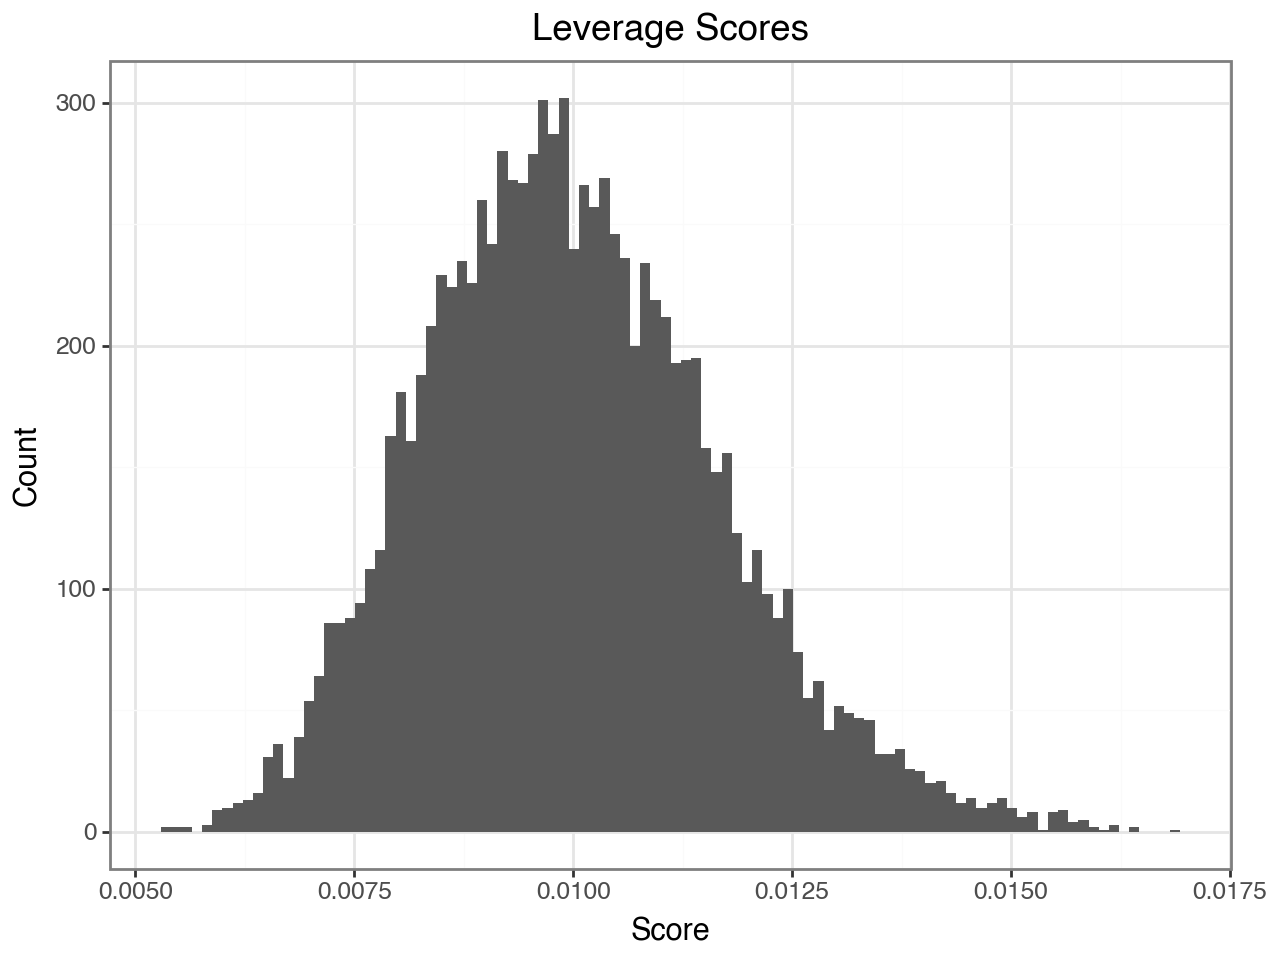

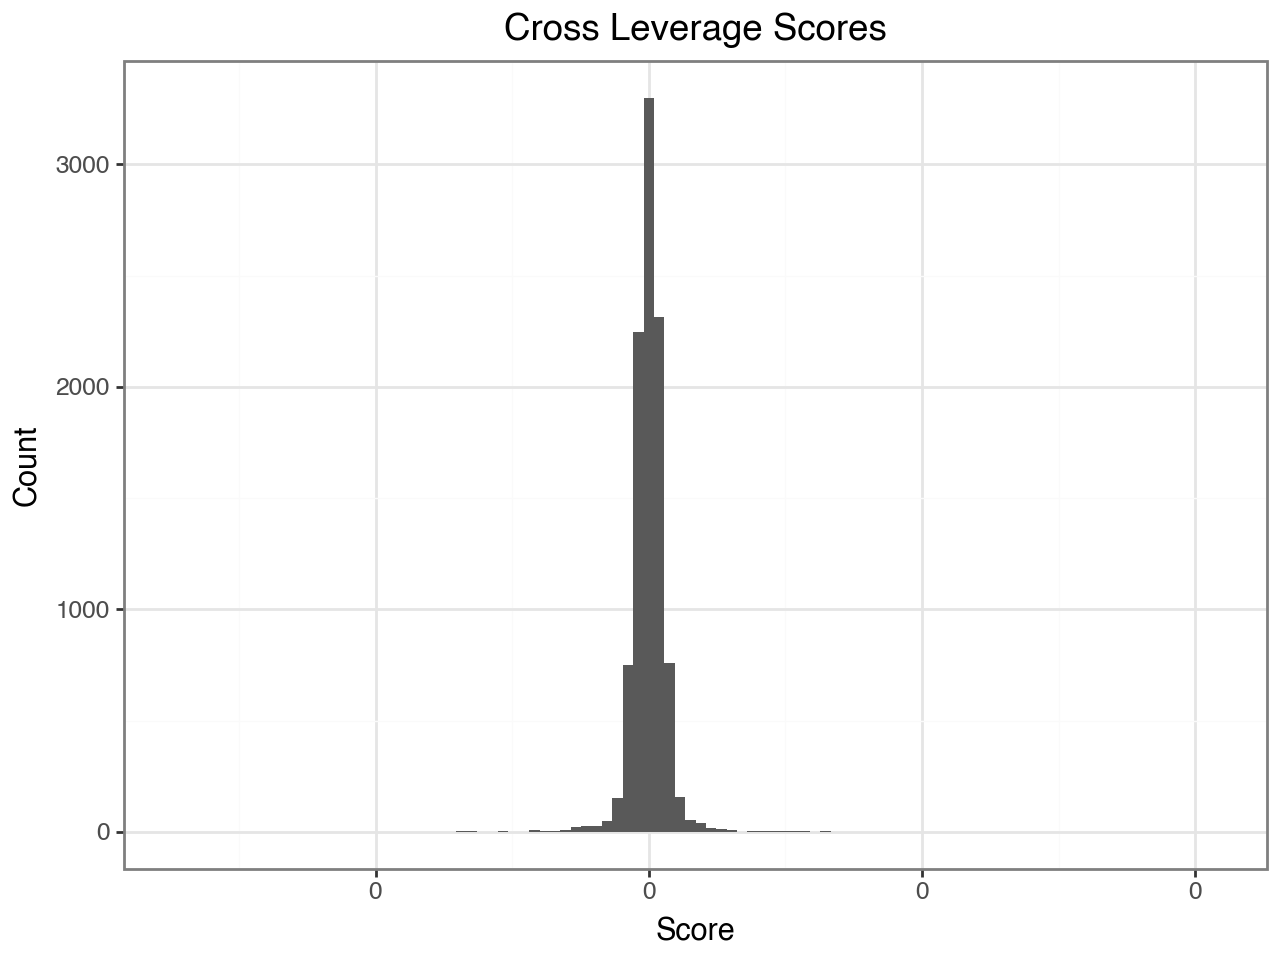

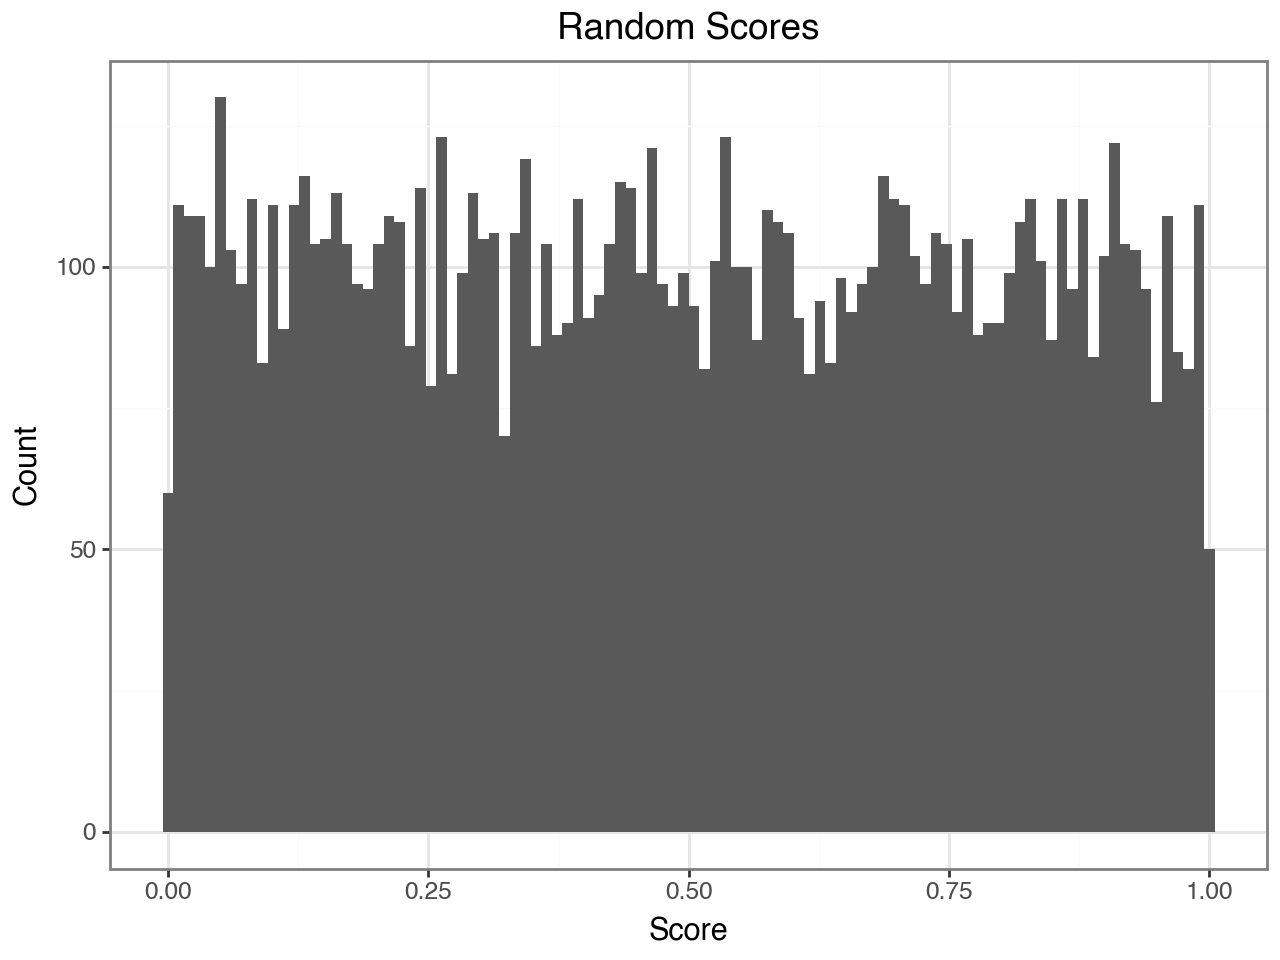

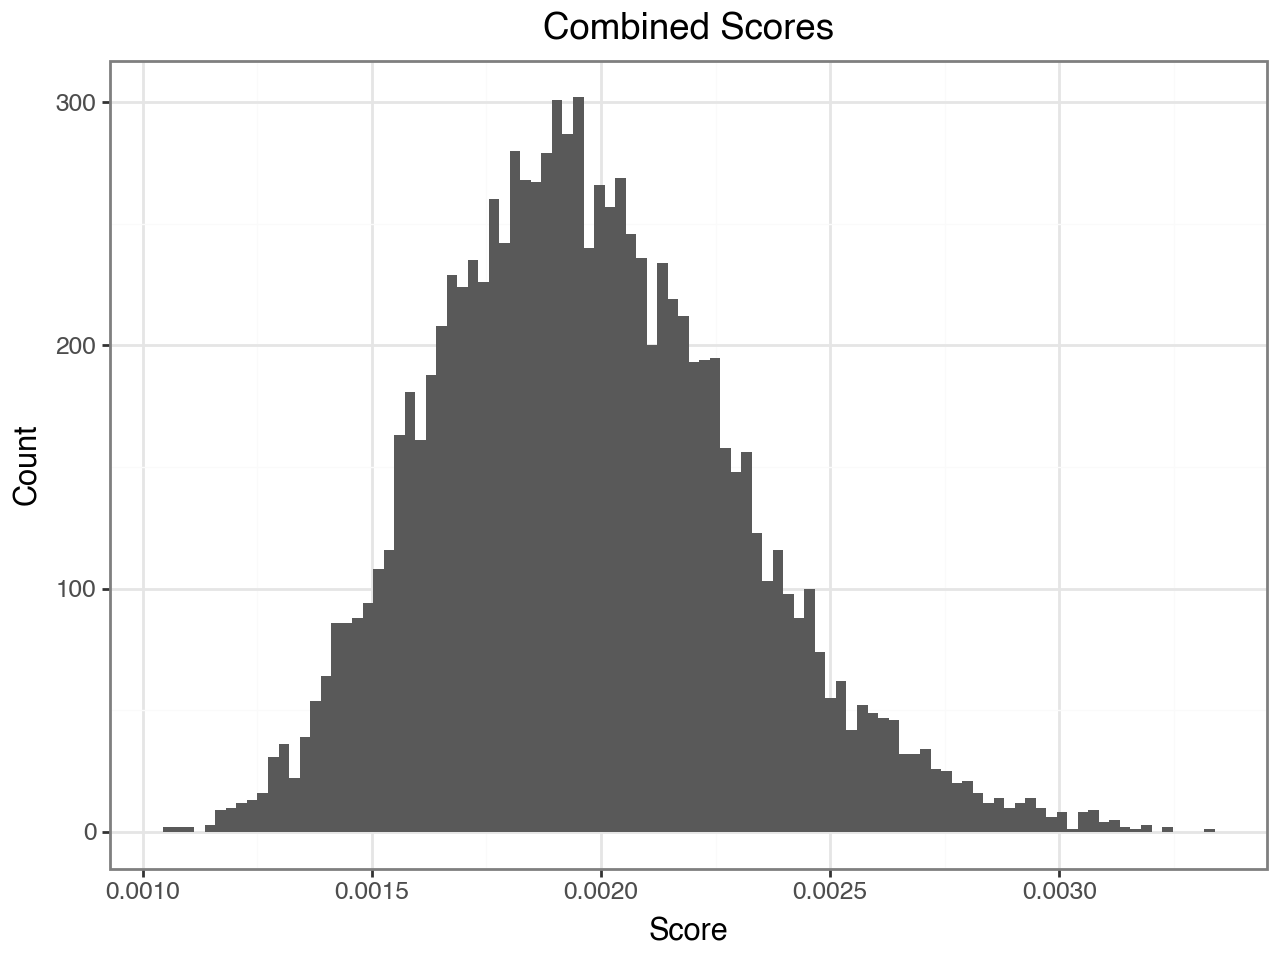

In [33]:
#==============================================================================================
# Scoring Mechanisms: Application of different scoring functions to the training data
#==============================================================================================

## Calculate the scores per data frame
column_ls = []
column_cls = []
column_rs = []
column_cs = []

for i in range(5):
    column_ls.append(get_leverage_scores(df_train[i], k))
    column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
    column_rs.append(get_random_scores(df_train[i]))
    column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))

## Investigation of distributions
df_ls  = pd.DataFrame({'value': column_ls[0]})
df_cls = pd.DataFrame({'value': column_cls[0]})
df_rs  = pd.DataFrame({'value': column_rs[0]})
df_cs  = pd.DataFrame({'value': column_cs[0]})

display(
    ggplot(df_ls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_cls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Cross Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_rs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Random Scores', x='Score', y='Count')
)

display(
    ggplot(df_cs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Combined Scores', x='Score', y='Count')
)

In [34]:
#==============================================================================================
# Column Reduction: Application of column reduction mechanism
#==============================================================================================

## Calculation of column reduction
C_ls = []
C_cls = []
C_rs = []
C_cs = []

for i in range(5):
    C_ls.append(column_reduction(df_train[i], column_ls[i], k))
    C_cls.append(column_reduction(df_train[i], column_cls[i], k))
    C_rs.append(column_reduction(df_train[i], column_rs[i], k))
    C_cs.append(column_reduction(df_train[i], column_cs[i], k))

In [35]:
#==============================================================================================
# Row Reduction: Application of row reduction mechanism
#==============================================================================================

## Calculation of row reduction
R_ls = []
R_cls = []
R_rs = []
R_cs = []

for i in range(5):
    R_ls.append(row_reduction(C_ls[i]['C'], y_train[i], k))
    R_cls.append(row_reduction(C_cls[i]['C'], y_train[i], k))
    R_rs.append(row_reduction(C_rs[i]['C'], y_train[i], k))
    R_cs.append(row_reduction(C_cs[i]['C'], y_train[i], k))

This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction nee

In [36]:
#==============================================================================================
# Linear Modeling: Application of linear model to reduced data sets, and RMSE calculations
#==============================================================================================

## Fit linear models to the reduced data matrix
model_ls = []
model_cls = []
model_rs = []
model_cs = []
for i in range(5):
    model = LinearRegression()
    model.fit(R_ls[i]['R'], R_ls[i]['y'])
    model_ls.append(model)
    model = LinearRegression()
    model.fit(R_cls[i]['R'], R_cls[i]['y'])
    model_cls.append(model)
    model = LinearRegression()
    model.fit(R_rs[i]['R'], R_rs[i]['y'])
    model_rs.append(model)
    model = LinearRegression()
    model.fit(R_cs[i]['R'], R_cs[i]['y'])
    model_cs.append(model)

## Build predictions
predictions_ls = []
predictions_cls = []
predictions_rs = []
predictions_cs = []
df_test_reduced_ls = []
df_test_reduced_cls = []
df_test_reduced_rs = []
df_test_reduced_cs = []
for i in range(5):
    df_test_reduced_ls.append(df_test[i].iloc[:, C_ls[i]['selected_columns']])
    predictions_ls.append(model_ls[i].predict(df_test_reduced_ls[i]))
    df_test_reduced_cls.append(df_test[i].iloc[:, C_cls[i]['selected_columns']])
    predictions_cls.append(model_cls[i].predict(df_test_reduced_cls[i]))
    df_test_reduced_rs.append(df_test[i].iloc[:, C_rs[i]['selected_columns']])
    predictions_rs.append(model_rs[i].predict(df_test_reduced_rs[i]))
    df_test_reduced_cs.append(df_test[i].iloc[:, C_cs[i]['selected_columns']])
    predictions_cs.append(model_cs[i].predict(df_test_reduced_cs[i]))

## Calculate RMSE
rmse_ls = []
rmse_cls = []
rmse_rs = []
rmse_cs = []
for i in range(5):
    rmse_ls.append(np.sqrt(mean_squared_error(y_test[i], predictions_ls[i])))
    rmse_cls.append(np.sqrt(mean_squared_error(y_test[i], predictions_cls[i])))
    rmse_rs.append(np.sqrt(mean_squared_error(y_test[i], predictions_rs[i])))
    rmse_cs.append(np.sqrt(mean_squared_error(y_test[i], predictions_cs[i])))

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester

In [47]:
#==============================================================================================
# Full Model: Application of Linear Model to the 
#==============================================================================================
beta_train = []
rmse_full = []
for i in range(1):
    beta_train.append(
        pd.read_csv(f"{base}/{folder}/rep0{i+1}/beta.csv")
    )
    beta = np.array(beta_train[i])
    selected_cols = np.where(beta[:, 1] != 0)[0]

    # Trainingsdaten reduzieren
    X_train_sel = df_train[i].iloc[:, selected_cols]
    X_test_sel = df_test[i].iloc[:, selected_cols]

    # y als 1D sicherstellen
    y_tr = np.ravel(y_train[i])
    y_te = np.ravel(y_test[i])

    # Modell fitten
    model = LinearRegression()
    model.fit(X_train_sel, y_tr)

    # Vorhersagen
    predictions = model.predict(X_test_sel)
    print(predictions)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_te, predictions))
    rmse_full.append(rmse)

rmse_df = pd.DataFrame({
    "LS": rmse_ls,
    "CLS": rmse_cls,
    "Combined": rmse_cs,
    "Random": rmse_rs,
    "Full": rmse_full
})


[-1.10301823e+01  2.82688405e+00 -1.85816090e-01 -4.97617693e+00
 -7.18596396e+00  2.41515823e+00 -6.14111473e+00 -3.30118530e+00
  9.74554305e+00 -1.82560740e+00 -1.47180196e+01 -2.36325972e+00
  1.52445326e+01  7.39433769e+00 -1.72044270e+01  3.05861990e+00
  5.79513726e+00  5.48482331e+00 -6.14092044e-01 -9.21411897e+00
 -6.33934646e+00  6.88903931e+00 -7.86876973e-03  1.19393834e+01
  3.64184629e-01  7.69005435e+00  8.01198266e+00  7.67781554e+00
  1.75447098e+01 -8.25116504e-02 -3.25385990e+00  2.20237112e+00
  7.03571478e-01  2.62174997e+00  1.56198955e+00 -4.71039646e+00
 -1.25493062e+01  2.03392534e+01 -9.36997552e+00  1.22301508e+01
  1.57021102e+00  5.95520098e+00  8.42473338e+00 -6.88751721e+00
  1.73074490e-03  3.38175914e+00  2.63487978e+00  1.64860974e+01
 -9.11606907e+00 -9.65992196e+00  1.22268215e+01 -4.66785128e+00
 -2.77548581e+00 -6.61658276e+00 -1.78425578e+01  9.88593172e+00
  1.78496543e+00 -9.92228690e+00 -2.44618280e+01 -1.39649396e+01
  2.00535421e+01  5.94569

ValueError: All arrays must be of the same length

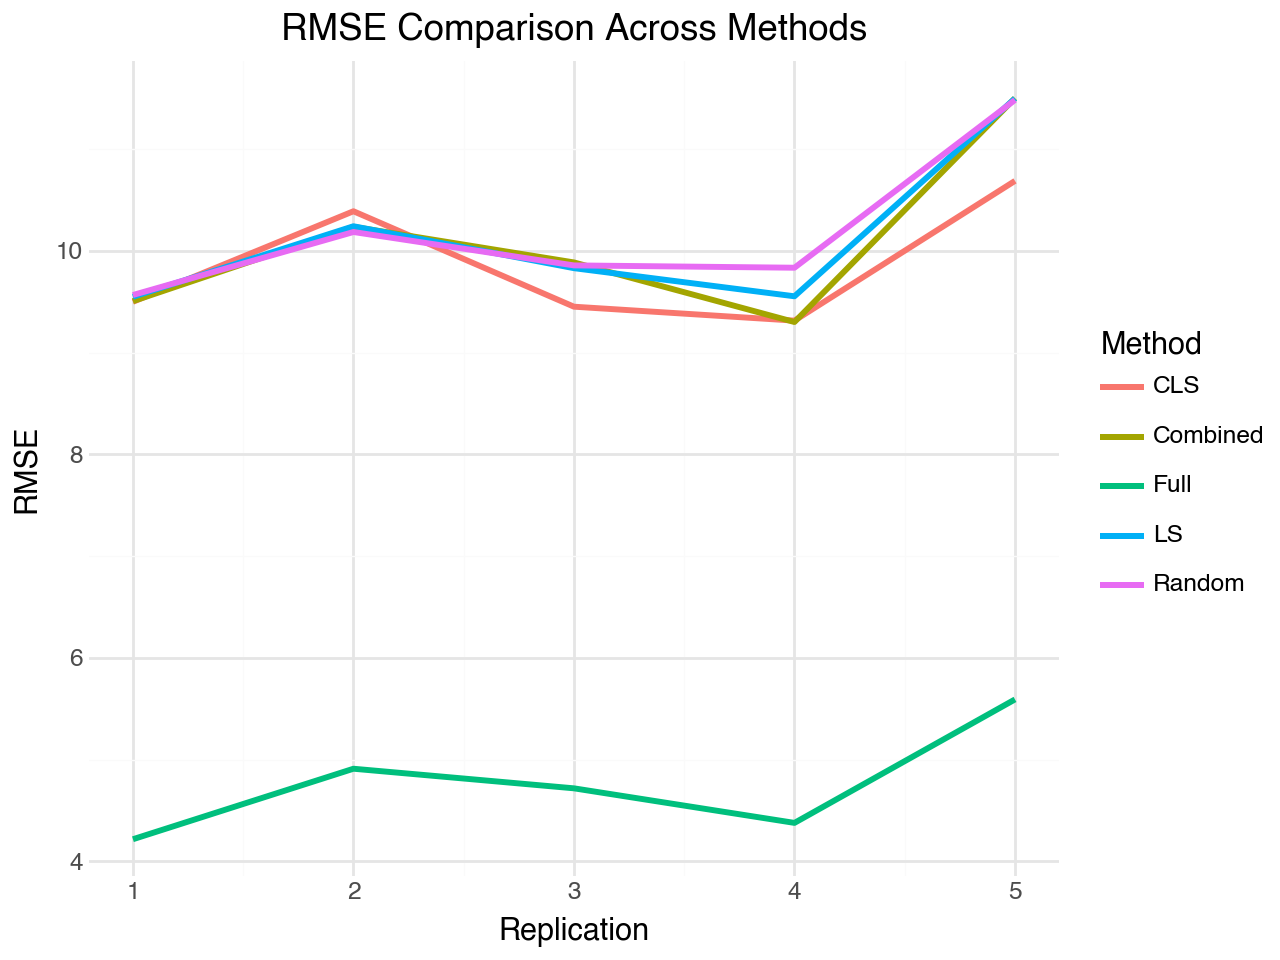

In [38]:
#==============================================================================================
# RMSE Plotting: Building a Line Chart over the RMSE values by Replication
#==============================================================================================

# Index = Replikation (x-Achse)
rmse_df["Replication"] = np.arange(1, len(rmse_ls) + 1)

# Von wide → long
rmse_long = rmse_df.melt(
    id_vars="Replication",
    var_name="Method",
    value_name="RMSE"
)
p_line = (
    ggplot(rmse_long, aes(x="Replication", y="RMSE", color="Method"))
    + geom_line(size=1.2)
    + theme_minimal()
    + labs(
        title="RMSE Comparison Across Methods",
        x="Replication",
        y="RMSE"
    )
)
display(p_line)
